# Stage 2: Flow Matching + Iterative CLF Correction

This notebook implements:
1. Bezier trajectory data generation
2. 1D UNet training with Flow Matching
3. **Piecewise FM sampling with CLF correction at each segment**

Key innovation: Instead of post-processing with CLF, we apply CLF correction **between each FM segment** during sampling.

Generating 8000 Bezier trajectories...
✓ Generated: (8000, 2, 100)


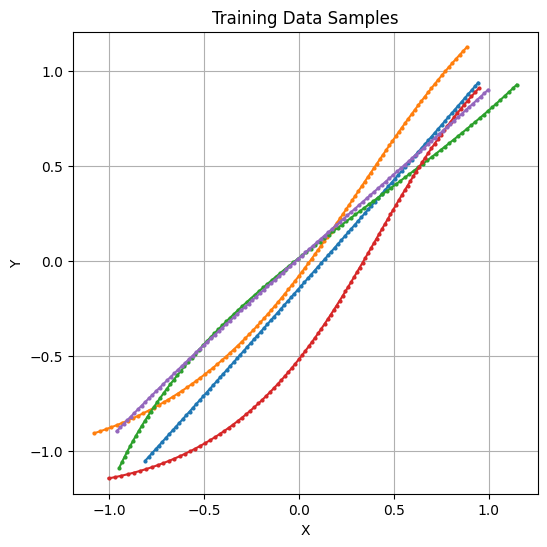

In [5]:
# Cell 0: Generate Bezier trajectory data (same as Stage 1)

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchdiffeq
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import minimize

def sample_point_in_circle(center, radius):
    angle = np.random.uniform(0, 2 * np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def generate_bezier_curve(P0, P1, P2, P3, num_points=100):
    t = np.linspace(0, 1, num_points).reshape(-1, 1)
    B_t = (1 - t)**3 * P0 + 3 * (1 - t)**2 * t * P1 + 3 * (1 - t) * t**2 * P2 + t**3 * P3
    return B_t

baseline_start = np.array([-1, -1])
baseline_end   = np.array([ 1,  1])
radius = 0.2
dominant_endpoint = "start"

if dominant_endpoint == "start":
    perturbation_scale_P1 = 0.7
    perturbation_scale_P2 = 0.01
elif dominant_endpoint == "end":
    perturbation_scale_P1 = 0.1
    perturbation_scale_P2 = 0.3
else:
    perturbation_scale_P1 = perturbation_scale_P2 = 0.2

num_trajectories = 8000
trajectories = []

print(f"Generating {num_trajectories} Bezier trajectories...")
for i in range(num_trajectories):
    P0 = sample_point_in_circle(baseline_start, radius)
    P3 = sample_point_in_circle(baseline_end, radius)
    
    base_vector = P3 - P0
    perp_vector = np.array([-base_vector[1], base_vector[0]])
    perp_vector = perp_vector / (np.linalg.norm(perp_vector) + 1e-8)
  
    P1 = P0 + base_vector / 3.0
    P2 = P0 + 2 * base_vector / 3.0
    
    P1 = P1 + np.random.uniform(-perturbation_scale_P1, perturbation_scale_P1) * perp_vector
    P2 = P2 + np.random.uniform(-perturbation_scale_P2, perturbation_scale_P2) * perp_vector
    
    curve = generate_bezier_curve(P0, P1, P2, P3, num_points=100)
    curve = curve.T
    trajectories.append(curve)

trajectories = np.array(trajectories)
print(f"✓ Generated: {trajectories.shape}")

# Visualize samples
num_plots = 5
indices = np.random.choice(len(trajectories), size=num_plots, replace=False)
plt.figure(figsize=(6, 6))
for idx in indices:
    traj = trajectories[idx]
    plt.plot(traj[0], traj[1], marker='o', linestyle='-', markersize=2)
plt.title("Training Data Samples")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.show()

In [2]:
# Cell 1: Define 1D UNet model (same as Stage 1)

import torch
import torch.nn as nn
import torch.nn.functional as F

from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories
        print(f"Dataset shape: {trajectories.shape}")
    def __len__(self):
        return len(self.trajectories)
    def __getitem__(self, idx):
        return torch.tensor(self.trajectories[idx], dtype=torch.float32)

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        emb = t * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class ResBlock1D(nn.Module):
    def __init__(self, channels, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(Mish(), nn.Linear(time_emb_dim, channels))
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels), Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels), Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
        )
    def forward(self, x, t_emb):
        h = self.block(x)
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)
        h = h + self.time_mlp(t_emb)[:, :, None]
        return x + h

class SimpleUNet1D(nn.Module):
    """
    Simplified 1D UNet for trajectory generation
    Input: (batch, 2, 100)
    Output: (batch, 2, 100)
    """
    def __init__(self, time_emb_dim=128, hidden_dim=128):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        
        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4), Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        # Encoder
        self.conv_in = nn.Conv1d(2, hidden_dim, 3, padding=1)
        
        # Level 1: 100 -> 50
        self.down1_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        self.down1_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        
        # Level 2: 50 -> 25
        self.down2_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        self.down2_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        
        # Middle: 25
        self.mid_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        
        # Decoder
        # Level 2: 25 -> 50
        self.up2_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up2_block = nn.ModuleList([ResBlock1D(hidden_dim * 2, time_emb_dim), ResBlock1D(hidden_dim * 2, time_emb_dim)])
        self.up2_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        # Level 1: 50 -> 100
        self.up1_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up1_block = nn.ModuleList([ResBlock1D(hidden_dim * 2, time_emb_dim), ResBlock1D(hidden_dim * 2, time_emb_dim)])
        self.up1_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        # Output
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, hidden_dim),
            Mish(),
            nn.Conv1d(hidden_dim, 2, 3, padding=1)
        )
    
    def forward(self, t, x, context=None):
        """
        Args:
            t: time step, shape (batch,) or scalar
            x: input trajectory, shape (batch, 2, 100)
            context: optional context (not used)
        Returns:
            velocity field, shape (batch, 2, 100)
        """
        # Time embedding
        t_emb = self.time_mlp(t)  # (batch, time_emb_dim)
        
        # Encoder
        h = self.conv_in(x)  # (batch, hidden_dim, 100)
        
        # Down 1
        for block in self.down1_block:
            h = block(h, t_emb)
        h1 = h  # Skip connection
        h = self.down1_sample(h)  # (batch, hidden_dim, 50)
        
        # Down 2
        for block in self.down2_block:
            h = block(h, t_emb)
        h2 = h  # Skip connection
        h = self.down2_sample(h)  # (batch, hidden_dim, 25)
        
        # Middle
        for block in self.mid_block:
            h = block(h, t_emb)
        
        # Up 2
        h = self.up2_sample(h)  # (batch, hidden_dim, 50)
        h = torch.cat([h, h2], dim=1)  # (batch, hidden_dim*2, 50)
        for block in self.up2_block:
            h = block(h, t_emb)
        h = self.up2_conv(h)  # (batch, hidden_dim, 50)
        
        # Up 1
        h = self.up1_sample(h)  # (batch, hidden_dim, 100)
        h = torch.cat([h, h1], dim=1)  # (batch, hidden_dim*2, 100)
        for block in self.up1_block:
            h = block(h, t_emb)
        h = self.up1_conv(h)  # (batch, hidden_dim, 100)
        
        # Output
        return self.conv_out(h)  # (batch, 2, 100)

# Create model
unet_1d = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)
print(f"✓ Model created with {sum(p.numel() for p in unet_1d.parameters()):,} parameters")

Using device: cuda
✓ Model created with 2,866,690 parameters


In [4]:
# Cell 2: Train the model (same as Stage 1)

# Prepare dataset
dataset = TrajectoryDataset(trajectories)
batch_size = 128
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

# Create Flow Matching components
fm_model = ModelWrapper(unet_1d).to(device)
scheduler = CondOTScheduler()
path = AffinePath(scheduler=scheduler)

# Training
optimizer = torch.optim.AdamW(unet_1d.parameters(), lr=1e-4, weight_decay=1e-5)
n_epochs = 50
loss_history = []

print(f"\nTraining for {n_epochs} epochs...")
print("="*70)

unet_1d.train()
for epoch in range(n_epochs):
    epoch_loss = 0.0
    for batch_idx, x1 in enumerate(dataloader):
        x1 = x1.to(device)  # (batch, 2, 100)
        
        # Sample x0 from standard Gaussian
        x0 = torch.randn_like(x1)
        
        # Sample time uniformly from (0.005, 0.995) to avoid endpoints
        t = torch.rand(x1.shape[0], device=device) * 0.99 + 0.005
        
        # Compute interpolated state and target velocity
        x_t, u_t = path.sample(x0=x0, x1=x1, t=t)
        
        # Predict velocity
        v_pred = fm_model(t=t, x=x_t, context=None)
        
        # Compute loss
        loss = F.mse_loss(v_pred, u_t)
        
        # Optimize
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet_1d.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        loss_history.append(loss.item())
    
    avg_loss = epoch_loss / len(dataloader)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.6f}")

print("="*70)
print("✓ Training complete")

# Plot training curve
plt.figure(figsize=(12, 4))
plt.plot(loss_history, alpha=0.3, label='Raw Loss')
if len(loss_history) > 100:
    ma = np.convolve(loss_history, np.ones(100)/100, mode='valid')
    plt.plot(range(50, 50+len(ma)), ma, linewidth=2, label='Moving Average (100)')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Dataset shape: (8000, 2, 100)

Training for 50 epochs...


TypeError: AffinePath.sample() got an unexpected keyword argument 'x0'. Did you mean 'x_0'?

In [ ]:
# Cell 3: Define CLF correction function

# CLF correction parameters
clf_params = {
    'a_max':      0.9,
    'delta_max':  0.9,
    'beta':       1e2,
    'lambda_reg': 1e2,
    'mask':       0.0,
    'cap':        1e3,
    'dt':         0.1,
    't_frac':     1.0
}

def time_blow_up_function(t, T=1.0, cap=1e3):
    """Time-varying CLF weight that increases near terminal time"""
    phi = 1.0 / (T - t + 1e-8)
    return min(phi, cap)

def simulate_vehicle(x0, controls, dt=0.1):
    """
    Simple kinematic bicycle model simulator
    Args:
        x0: initial state [x, y, theta, v, r] (5,)
        controls: control sequence (N, 2) with [a, delta]
        dt: time step
    Returns:
        states: trajectory (N+1, 5)
    """
    N = controls.shape[0]
    states = np.zeros((N+1, 5))
    states[0] = x0
    
    L = 2.5  # wheelbase
    
    for i in range(N):
        x, y, theta, v, r = states[i]
        a, delta = controls[i]
        
        # Kinematic bicycle model
        x_dot = v * np.cos(theta)
        y_dot = v * np.sin(theta)
        theta_dot = v * np.tan(delta) / L
        v_dot = a
        r_dot = 0.0  # r is not used in simple model
        
        # Euler integration
        states[i+1, 0] = x + x_dot * dt
        states[i+1, 1] = y + y_dot * dt
        states[i+1, 2] = theta + theta_dot * dt
        states[i+1, 3] = v + v_dot * dt
        states[i+1, 4] = r + r_dot * dt
    
    return states

def correct_with_clf(states_phys, controls_phys, clf_params):
    """
    CLF-based trajectory correction
    
    Args:
        states_phys: physical state sequence (N, 5) - [x, y, theta, v, r]
        controls_phys: physical control sequence (N, 2) - [a, delta]
        clf_params: CLF correction parameters
    
    Returns:
        corrected_controls: (N, 2)
    
    Objective:
        min_{du} β*w_s*||simulate(U+du) - S||^2 + λ||du||^2
        s.t. U+du within control bounds
    """
    N = states_phys.shape[0]
    a_max, d_max = clf_params['a_max'], clf_params['delta_max']
    λ_reg, β     = clf_params['lambda_reg'], clf_params['beta']
    cap, dt      = clf_params['cap'], clf_params['dt']
    phi  = time_blow_up_function(clf_params['t_frac'], cap=cap)
    w_s  = phi / (1.0 + phi)

    # Initial state with extended dimensions [x, y, theta, v, r]
    x0 = np.array([*states_phys[0], 0.0, 0.0], dtype=np.float32)
    u0 = np.zeros(N*2, dtype=np.float32)

    def obj(du_flat):
        """Objective: tracking error + control penalty"""
        du = du_flat.reshape(N, 2)
        U  = controls_phys + du
        
        # Simulate with corrected controls
        pred = simulate_vehicle(x0, U[:-1], dt=dt)[:, :3]  # Only use [x, y, theta]
        
        # State tracking error (only position)
        err = pred - states_phys
        
        return β * w_s * np.sum(err**2) + λ_reg * np.sum(du**2)

    # Control bounds
    bnds = []
    for k in range(N):
        a0, d0 = controls_phys[k]
        bnds += [(-a_max - a0, a_max - a0),
                 (-d_max - d0, d_max - d0)]

    # Optimize
    res = minimize(obj, u0, method='SLSQP', bounds=bnds,
                   options={'ftol': 1e-6, 'maxiter': 200})
    
    du_opt = res.x.reshape(N, 2).astype(np.float32)
    return controls_phys + du_opt

print("✓ CLF correction function defined")

In [ ]:
# Cell 4: Define data scalers

class Scaler:
    """Min-Max scaler for normalizing data to [-1, 1]"""
    def __init__(self, data_min, data_max):
        self.min = data_min
        self.max = data_max
    
    def normalize(self, x):
        return 2 * (x - self.min) / (self.max - self.min) - 1
    
    def denormalize(self, x):
        return (x + 1) / 2 * (self.max - self.min) + self.min

# For this simple trajectory data, we assume states are [x, y] only
# and we'll create dummy controls later
state_min = trajectories.min(axis=(0, 2))
state_max = trajectories.max(axis=(0, 2))

# Extend to 5D for vehicle model: [x, y, theta, v, r]
# We'll set dummy values for theta, v, r
dmin_5d = np.array([state_min[0], state_min[1], -np.pi, 0.0, -1.0])
dmax_5d = np.array([state_max[0], state_max[1], np.pi, 2.0, 1.0])

state_scaler = Scaler(dmin_5d, dmax_5d)

# Control scaler [a, delta]
control_min = np.array([-0.9, -0.9])
control_max = np.array([0.9, 0.9])
control_scaler = Scaler(control_min, control_max)

print("✓ Scalers initialized")
print(f"  State range: {state_min} to {state_max}")
print(f"  Control range: {control_min} to {control_max}")

In [ ]:
# Cell 5: Piecewise FM sampling with iterative CLF correction

def piecewise_fm_with_clf(x0_norm, unet, num_segments, clf_params, state_scaler, control_scaler):
    """
    Piecewise Flow Matching with CLF correction at each segment
    
    Args:
        x0_norm: initial noise, shape (1, 2, 100)
        unet: trained SimpleUNet1D model (with forward(x, t) signature)
        num_segments: number of ODE integration segments
        clf_params: CLF correction parameters
        state_scaler: scaler for states
        control_scaler: scaler for controls
    
    Returns:
        final_state: corrected trajectory (1, 2, 100)
        correction_history: list of corrections applied
    """
    device = x0_norm.device
    times = torch.linspace(0, 1, num_segments + 1, device=device)
    state = x0_norm.clone()
    
    correction_history = []
    
    # Define ODE function for dopri5
    def ode_func(t, x_flat):
        x = x_flat.view(1, 2, 100)
        with torch.no_grad():
            # Note: SimpleUNet1D uses forward(x, t) not forward(t, x)
            v = unet(x, t)
        return v.view(-1)
    
    # Iterative FM + CLF correction
    for i in range(num_segments):
        # 1. Flow Matching step: integrate from t_i to t_{i+1}
        tspan = times[i:i+2]
        traj = torchdiffeq.odeint(
            ode_func,
            state.view(-1),
            tspan,
            method='dopri5',
            atol=1e-5,
            rtol=1e-5
        )
        state_after_fm = traj[-1].view(1, 2, 100)
        
        # 2. CLF correction step
        # Convert to physical coordinates
        arr_norm = state_after_fm.cpu().numpy()[0].T  # (100, 2)
        
        # Extend to 5D with dummy values for vehicle model
        arr_5d_norm = np.zeros((100, 5))
        arr_5d_norm[:, :2] = arr_norm  # x, y
        # theta, v, r remain 0 in normalized space
        
        arr_5d_phys = state_scaler.denormalize(arr_5d_norm)  # (100, 5)
        
        # Extract states and create dummy controls
        S = arr_5d_phys[:, :3]  # [x, y, theta]
        
        # Create reasonable dummy controls based on trajectory
        dx = np.diff(arr_5d_phys[:, 0], prepend=arr_5d_phys[0, 0])
        dy = np.diff(arr_5d_phys[:, 1], prepend=arr_5d_phys[0, 1])
        v_est = np.sqrt(dx**2 + dy**2) / clf_params['dt']
        a_est = np.diff(v_est, prepend=v_est[0]) / clf_params['dt']
        a_est = np.clip(a_est, -0.5, 0.5)
        
        # Steering angle from heading change
        delta_est = np.arctan2(dy, dx + 1e-8)
        delta_est = np.clip(delta_est, -0.5, 0.5)
        
        U = np.stack([a_est, delta_est], axis=1)  # (100, 2)
        
        # Apply CLF correction
        U_corr = correct_with_clf(S, U, clf_params)
        
        # Store correction magnitude
        correction_mag = np.linalg.norm(U_corr - U)
        correction_history.append(correction_mag)
        
        # Simulate with corrected controls to get corrected states
        x0_sim = np.array([*S[0], 0.0, 0.0], dtype=np.float32)
        S_corr = simulate_vehicle(x0_sim, U_corr[:-1], dt=clf_params['dt'])[:, :3]
        
        # Update 5D array with corrected states
        arr_5d_phys[:, :3] = S_corr
        
        # Normalize back
        arr_5d_norm_corr = state_scaler.normalize(arr_5d_phys)
        arr_norm_corr = arr_5d_norm_corr[:, :2]  # Extract x, y
        
        # Convert back to tensor
        state = torch.from_numpy(arr_norm_corr.T[None, :, :]).float().to(device)
    
    return state, correction_history

print("✓ Piecewise FM with CLF function defined")

In [ ]:
# Cell 6: Run sampling and visualization

num_segments = 10  # Number of FM segments
num_samples = 8

unet_1d.eval()

# Note: We use unet_1d directly (SimpleUNet1D) rather than fm_model (ModelWrapper)
# because SimpleUNet1D has the forward(x, t) signature that our piecewise_fm_with_clf expects

print(f"\nGenerating {num_samples} trajectories with {num_segments} segments...")
print("="*70)

generated_trajs = []
all_corrections = []

with torch.no_grad():
    for i in range(num_samples):
        # Sample initial noise
        x0_noise = torch.randn(1, 2, 100, device=device)
        
        # Generate with CLF correction
        traj_corrected, corrections = piecewise_fm_with_clf(
            x0_noise, unet_1d, num_segments, clf_params, state_scaler, control_scaler
        )
        
        generated_trajs.append(traj_corrected.cpu().numpy()[0])
        all_corrections.append(corrections)
        
        print(f"  Trajectory {i+1}: Average correction = {np.mean(corrections):.4f}")

generated_trajs = np.array(generated_trajs)  # (num_samples, 2, 100)

print("="*70)
print(f"✓ Generation complete")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Generated trajectories
ax = axes[0, 0]
for i in range(num_samples):
    ax.plot(generated_trajs[i, 0], generated_trajs[i, 1], 
            marker='o', markersize=2, alpha=0.6, linewidth=1.5)
ax.set_title("Generated Trajectories with CLF Correction", fontweight='bold')
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, alpha=0.3)
ax.axis('equal')

# Plot 2: Training data samples for comparison
ax = axes[0, 1]
rand_indices = np.random.choice(trajectories.shape[0], size=num_samples, replace=False)
for idx in rand_indices:
    ax.plot(trajectories[idx, 0], trajectories[idx, 1], 
            marker='o', markersize=2, alpha=0.6, linewidth=1.5)
ax.set_title("Training Data Samples", fontweight='bold')
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, alpha=0.3)
ax.axis('equal')

# Plot 3: Correction magnitude over segments
ax = axes[1, 0]
for i, corrections in enumerate(all_corrections):
    ax.plot(corrections, marker='o', alpha=0.6, label=f'Traj {i+1}')
ax.set_title("CLF Correction Magnitude per Segment", fontweight='bold')
ax.set_xlabel("Segment")
ax.set_ylabel("Correction Magnitude")
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=8, ncol=2)

# Plot 4: Overlay comparison
ax = axes[1, 1]
for idx in rand_indices:
    ax.plot(trajectories[idx, 0], trajectories[idx, 1], 
            'b-', alpha=0.3, linewidth=2)
for i in range(num_samples):
    ax.plot(generated_trajs[i, 0], generated_trajs[i, 1], 
            'r-', alpha=0.5, linewidth=2)
ax.plot([], [], 'b-', alpha=0.5, linewidth=2, label='Real')
ax.plot([], [], 'r-', alpha=0.7, linewidth=2, label='Generated')
ax.set_title("Real vs Generated Comparison", fontweight='bold')
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, alpha=0.3)
ax.legend()
ax.axis('equal')

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete")

In [ ]:
# Cell 7: Analysis and statistics

print("\n" + "="*70)
print("ANALYSIS SUMMARY")
print("="*70)

# Correction statistics
all_corr_flat = [c for traj_corr in all_corrections for c in traj_corr]
print(f"\nCLF Correction Statistics:")
print(f"  Mean correction: {np.mean(all_corr_flat):.4f}")
print(f"  Std correction:  {np.std(all_corr_flat):.4f}")
print(f"  Max correction:  {np.max(all_corr_flat):.4f}")
print(f"  Min correction:  {np.min(all_corr_flat):.4f}")

# Trajectory statistics
print(f"\nTrajectory Statistics:")
start_points = generated_trajs[:, :, 0]
end_points = generated_trajs[:, :, -1]
print(f"  Start points mean: [{np.mean(start_points[:, 0]):.3f}, {np.mean(start_points[:, 1]):.3f}]")
print(f"  End points mean:   [{np.mean(end_points[:, 0]):.3f}, {np.mean(end_points[:, 1]):.3f}]")
print(f"  Start points std:  [{np.std(start_points[:, 0]):.3f}, {np.std(start_points[:, 1]):.3f}]")
print(f"  End points std:    [{np.std(end_points[:, 0]):.3f}, {np.std(end_points[:, 1]):.3f}]")

# Compare with training data
train_start = trajectories[:, :, 0]
train_end = trajectories[:, :, -1]
print(f"\nComparison with Training Data:")
print(f"  Training start mean: [{np.mean(train_start[:, 0]):.3f}, {np.mean(train_start[:, 1]):.3f}]")
print(f"  Training end mean:   [{np.mean(train_end[:, 0]):.3f}, {np.mean(train_end[:, 1]):.3f}]")

print("\n" + "="*70)
print("✓ Analysis complete")
print("="*70)